# Práctica: Clustering de jugadores en FIFA22 con aprendizaje no supervisado

### Objetivos
En esta práctica exploraremos distintas técnicas de **aprendizaje no supervisado** aplicadas al análisis de datos de jugadores de FIFA22.

El propósito es **agrupar jugadores según sus habilidades** y contrastar con posiciones reales en el campo, siguiendo la línea del artículo *"Clustering in Game Analysis on FIFA22 Official Players Data"* (IEEE AiDAS, 2022) y tomando como inspiración un trabajo destacado del curso 2024–25.


- Preprocesamiento y selección de atributos.
- Reducción de dimensionalidad con **PCA**.
- Comparación de **K-Means**, **Clustering Jerárquico (HC)** y **DBSCAN**.
- Exploración de **algoritmos alternativos** (GMM, Spectral, OPTICS, Birch...).
- Interpretación mediante **métricas** y **visualización**.


## 1. Preparación del entorno

**Tareas:**
1. Importar librerías necesarias (`pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`).
2. Cargar el dataset oficial de FIFA22 desde Kaggle (`players_22.csv`).
3. Mostrar dimensiones y primeras filas.


In [606]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeRegressor

df = pd.read_csv('players_22.csv')
df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14832\3528917537.py:14: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('players_22.csv')


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


## 2. Exploración y limpieza de datos

**Posibles tareas: (opcional)**
1. Elimina jugadores **porteros (GK)** y sus variables específicas.
2. Descarta columnas **no numéricas o irrelevantes** (identificadores, URL, nombres, club, nacionalidad, etc.).
3. Elimina atributos **posicionales derivados** (LS, ST, RS, LW, RW, ...) de los datos de entrada. Pueden servirte como etiquetas para comprobar si el clustering es efectivo.
4. Rellena valores nulos (por ejemplo, con la **media**).
5. Aplica un **filtro de calidad**: conserva jugadores con `overall` **> 70**.
6. Verifica el tamaño final del dataset y el % de nulos.


In [607]:
# Me cargo a los porteros porque no me interesan para el análisis, ya que sus estadísticas son muy diferentes al resto de jugadores y podrían distorsionar el análisis.
df_no_gk = df[~df['player_positions'].str.contains('GK', na=False)]
df_no_gk.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [608]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(16), int64(44), object(50)
memory usage: 16.1+ MB


In [609]:
# estas variables que son no numéricas me las voy a guardar ya que me parece interesante conservarlas, lo único que las voy a transformar a no numericas. Para eso uso el .map
df_no_gk['preferred_foot_num'] = df_no_gk['preferred_foot'].map({'Left': 0, 'Right': 1}).fillna(1)
df_no_gk['real_face_num'] = df_no_gk['real_face'].map({False: 0, True: 1}).fillna(0)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14832\1288472004.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_gk['preferred_foot_num'] = df_no_gk['preferred_foot'].map({'Left': 0, 'Right': 1}).fillna(1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_14832\1288472004.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_gk['real_face_num'] = df_no_gk['real_face'].map({False: 0, True: 1}).fillna(0)


In [610]:
work_map = {'Low/Low':0, 'Medium/Low':1, 'Low/Medium':1, 'Medium/Medium':2, 
            'High/Low':2, 'Medium/High':3, 'High/Medium':3, 'High/High':3}
df_no_gk['work_rate_num'] = df_no_gk['work_rate'].map(work_map).fillna(2)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14832\928505336.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_gk['work_rate_num'] = df_no_gk['work_rate'].map(work_map).fillna(2)


In [611]:
body_map = {'Lean':1, 'Normal':0, 'Stocky':3, 'Lean (170-)':1, 'Normal (170-)':0}
df_no_gk['body_type_num'] = df_no_gk['body_type'].map(body_map).fillna(0)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14832\1611921016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_gk['body_type_num'] = df_no_gk['body_type'].map(body_map).fillna(0)


In [612]:
# Ahora me voy a cargar todas las columnas que creo que no sean necesarias, todas aquellas que no contentan variables numéricas o que no aporten información relevante para el análisis.
columns_to_drop = ['sofifa_id', 'player_url', 'short_name', 'player_position','long_name', 'dob', 'club_jersey_number', 'nation_jersey_number','release_clause_eur','club_position', 'club_joined', 'club_contract_valid_until', 'nation_position','club_jersey_number', 'club_loaned_from', 'nationality_name' , 'nationality_id','nation_team_id','league_name', 'club_name', 'club_team_id' ,'player_face_url', 'player_tags','player_traits','club_logo_url', 'club_flag_url', 'nation_logo_url', 'nation_flag_url']
object_cols = df_no_gk.select_dtypes(exclude=[np.number]).columns.tolist()
df_stats = df_no_gk.drop(columns=object_cols)
df_stats.head()

,sofifa_id,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,...,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,preferred_foot_num,real_face_num,work_rate_num,body_type_num
0,158023,93,93,78000000.0,320000.0,34,170,72,73.0,1.0,...,6,11,15,14,8,NaN,0,0.0,1.0,0.0
1,188545,92,92,119500000.0,270000.0,32,185,81,21.0,1.0,...,15,6,12,8,10,NaN,1,0.0,3.0,0.0
2,20801,91,91,45000000.0,270000.0,36,187,83,11.0,1.0,...,7,11,15,14,11,NaN,1,0.0,2.0,0.0
3,190871,91,91,129000000.0,270000.0,29,175,68,73.0,1.0,...,9,9,15,15,11,NaN,1,0.0,3.0,0.0
4,192985,91,91,125500000.0,350000.0,30,181,70,10.0,1.0,...,15,13,5,10,13,NaN,1,0.0,3.0,0.0


In [613]:
# Una vez eliminadas las columnas que no son numéricas, voy a cargarme otras que considero que no tienen importancia
columns_to_drop = ['sofifa_id', 'value_eur','wage_eur','international_reputation', 'weak_foot', 'skill_moves' , 'club_jersey_number', 'league_level','nation_jersey_number','release_clause_eur','club_contract_valid_until','club_jersey_number', 'nationality_id','nation_team_id','club_team_id']
df_stats = df_stats.drop(columns=columns_to_drop)
df_stats.head()


,overall,potential,age,height_cm,weight_kg,pace,shooting,passing,dribbling,defending,...,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,preferred_foot_num,real_face_num,work_rate_num,body_type_num
0,93,93,34,170,72,85.0,92.0,91.0,95.0,34.0,...,6,11,15,14,8,NaN,0,0.0,1.0,0.0
1,92,92,32,185,81,78.0,92.0,79.0,86.0,44.0,...,15,6,12,8,10,NaN,1,0.0,3.0,0.0
2,91,91,36,187,83,87.0,94.0,80.0,88.0,34.0,...,7,11,15,14,11,NaN,1,0.0,2.0,0.0
3,91,91,29,175,68,91.0,83.0,86.0,94.0,37.0,...,9,9,15,15,11,NaN,1,0.0,3.0,0.0
4,91,91,30,181,70,76.0,86.0,93.0,88.0,64.0,...,15,13,5,10,13,NaN,1,0.0,3.0,0.0


In [614]:
# Voy a eliminar también las columnas relacionadas con el portero, ya que me he cargadado ya previamente a los porteros.
columns_to_drop = [col for col in df_stats.columns if 'goalkeeping' in col]
df_stats = df_stats.drop(columns=columns_to_drop)
df_stats.head()

,overall,potential,age,height_cm,weight_kg,pace,shooting,passing,dribbling,defending,...,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,preferred_foot_num,real_face_num,work_rate_num,body_type_num
0,93,93,34,170,72,85.0,92.0,91.0,95.0,34.0,...,95,75,96,20,35,24,0,0.0,1.0,0.0
1,92,92,32,185,81,78.0,92.0,79.0,86.0,44.0,...,81,90,88,35,42,19,1,0.0,3.0,0.0
2,91,91,36,187,83,87.0,94.0,80.0,88.0,34.0,...,76,88,95,24,32,24,1,0.0,2.0,0.0
3,91,91,29,175,68,91.0,83.0,86.0,94.0,37.0,...,90,93,93,35,32,29,1,0.0,3.0,0.0
4,91,91,30,181,70,76.0,86.0,93.0,88.0,64.0,...,94,83,89,68,65,53,1,0.0,3.0,0.0


In [615]:
# Hay varios jugadores con valores NA, en el próximo bloque las relleno con la media
df_stats = df_stats.fillna(df_stats.mean())
# Ahora debería de haber 0 nulos
print(df_stats.isna().sum())

overall                        0
potential                      0
age                            0
height_cm                      0
weight_kg                      0
pace                           0
shooting                       0
passing                        0
dribbling                      0
defending                      0
physic                         0
attacking_crossing             0
attacking_finishing            0
attacking_heading_accuracy     0
attacking_short_passing        0
attacking_volleys              0
skill_dribbling                0
skill_curve                    0
skill_fk_accuracy              0
skill_long_passing             0
skill_ball_control             0
movement_acceleration          0
movement_sprint_speed          0
movement_agility               0
movement_reactions             0
movement_balance               0
power_shot_power               0
power_jumping                  0
power_stamina                  0
power_strength                 0
power_long

In [616]:
# Me cargo a los que tienen un overall menor a 70, así me centro en jugadores con mejores cualidades
df_stats = df_stats.drop(df_stats[df_stats['overall'] < 70].index)

In [617]:
# me queda un df mucho más pequeño que el original.
print('df_stats shape: ',df_stats.shape)
print('df shape: ', df.shape)

df_stats shape:  (4935, 44)
df shape:  (19239, 110)


## 3. Selección de características y normalización

**Tareas guiadas:**
1. (Opcional) Selección de características para eliminar redundancia (p.ej. árbol de decisión por-feature con R² alto).
2. Escala los datos (StandardScaler o MinMaxScaler).
3. (Opcional) Aplica **transformación log** si fuera necesario.
4. Visualiza histogramas antes y después.


In [618]:
# Voy a hacer una selección de características
X = df_stats.drop('overall', axis=1)
y = df_stats['overall']

tree = DecisionTreeRegressor(random_state=42) # a través de este árbol vamos a predecir números continuos
# El árbol va a utilizar overall para poder predecir el resto de características, es la variable objetivo ya que es el indicador global de cada jugador.

tree.fit(X, y) # esta es la forma de entrenar el árbol, le paso el df y la variable objetivo.
importances = pd.DataFrame({'feature':X.columns, 'importance':tree.feature_importances_}) # esta es la forma de obtener la importancia de cada variable, me devuelve un array con la importancia de cada variable.
# básicamente, después de entrenar te die las variables más útiles para predecir el overall que hemos puesto como variable objetivo.
print(importances.sort_values('importance', ascending=False).head(40)) # esta es la forma de ordenar las variables por importancia, de mayor a menor.
# Además, voy a escalar con StandarScaler.



                        feature  importance
23           movement_reactions    0.620735
0                     potential    0.206429
19           skill_ball_control    0.034267
8                     defending    0.023972
1                           age    0.023446
37    defending_standing_tackle    0.013440
10           attacking_crossing    0.011493
7                     dribbling    0.005495
32        mentality_positioning    0.005219
6                       passing    0.004743
13      attacking_short_passing    0.004142
5                      shooting    0.003860
38     defending_sliding_tackle    0.003816
9                        physic    0.002867
33             mentality_vision    0.002215
28               power_strength    0.002124
12   attacking_heading_accuracy    0.002092
4                          pace    0.002051
26                power_jumping    0.001993
27                power_stamina    0.001985
21        movement_sprint_speed    0.001824
35          mentality_composure 

In [619]:
# Me quedo con las top features, las que superen el umbral del 0.001.
to_remove = importances[importances['importance'] < 0.001]['feature'].tolist()
to_remove = [col.strip() for col in to_remove if col in df_stats.columns]
df_top_features = df_stats.drop(columns=to_remove, axis=1)
print(df_top_features.shape)
df_top_features.head()

(4935, 35)


,overall,potential,age,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,...,power_strength,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle
0,93,93,34,85.0,92.0,91.0,95.0,34.0,65.0,85,...,69,44,40,93,95,75,96,20,35,24
1,92,92,32,78.0,92.0,79.0,86.0,44.0,82.0,71,...,86,81,49,95,81,90,88,35,42,19
2,91,91,36,87.0,94.0,80.0,88.0,34.0,75.0,87,...,77,63,29,95,76,88,95,24,32,24
3,91,91,29,91.0,83.0,86.0,94.0,37.0,63.0,85,...,53,63,37,86,90,93,93,35,32,29
4,91,91,30,76.0,86.0,93.0,88.0,64.0,78.0,94,...,74,76,66,88,94,83,89,68,65,53


In [620]:
df_scaled = StandardScaler().fit_transform(df_top_features)
print('Variables Escaladas: ', df_scaled.shape)
print(df_scaled)

Variables Escaladas:  (4935, 35)
[[ 5.1607105   3.56544333  1.6777995  ... -2.0410234  -1.18565906
  -1.53939982]
 [ 4.88968382  3.35130063  1.18214308 ... -1.22528184 -0.83117732
  -1.78555495]
 [ 4.61865713  3.13715794  2.17345592 ... -1.82349232 -1.3375798
  -1.53939982]
 ...
 [-1.07290319 -1.14569596 -0.05699798 ...  0.95002898  0.73867036
   0.92215149]
 [-1.07290319  0.5674456  -2.03962367 ... -1.00775076 -1.23629931
  -0.99785853]
 [-1.07290319  0.99573099 -2.53528009 ... -0.1920092  -0.47669559
  -0.60401032]]


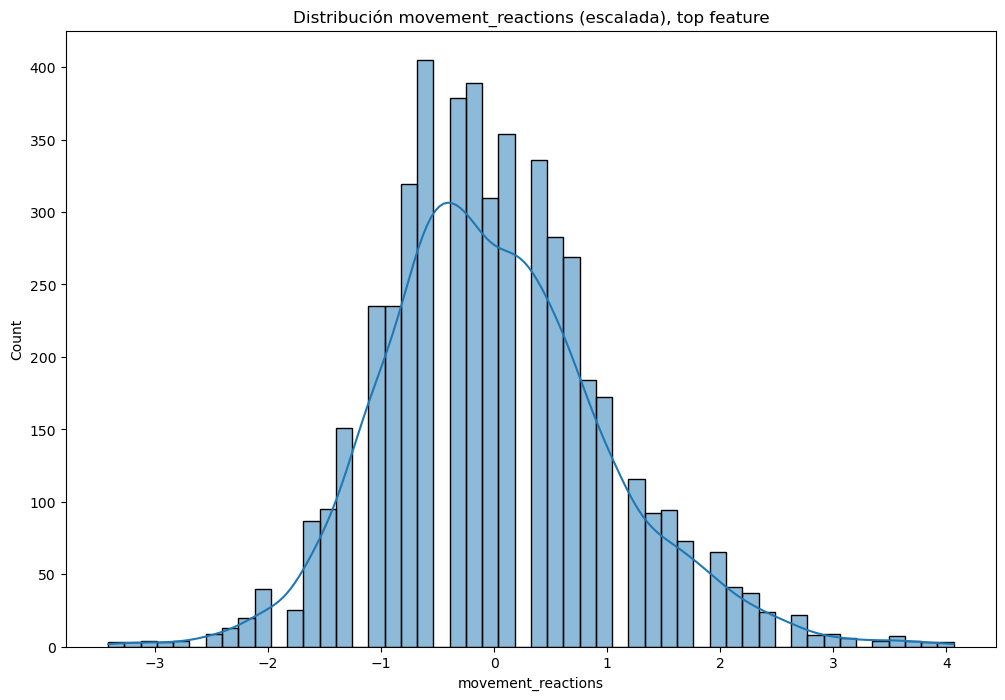

In [621]:
# Ahora lo represento con un histograma del top10 features que más influyen en el overall
df_scaled_DataFrame = pd.DataFrame(df_scaled, columns=df_top_features.columns)
plt.figure(figsize=(12, 8))
sns.histplot(data=df_scaled_DataFrame, x='movement_reactions', kde=True)  # Top feature
plt.title('Distribución movement_reactions (escalada), top feature')
plt.show()

In [622]:
df_scaled_DataFrame.head(5)

,overall,potential,age,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,...,power_strength,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle
0,5.160710,3.565443,1.677799,1.214344,2.301092,3.019101,3.059449,-1.412264,-0.643566,1.701581,...,-0.097358,-1.797524,-0.921863,2.033685,2.558797,1.313553,3.676461,-2.041023,-1.185659,-1.539400
1,4.889684,3.351301,1.182143,0.626247,2.301092,1.574931,1.946391,-0.829162,1.404299,0.646246,...,1.364050,1.059236,-0.454929,2.171412,1.385783,2.456710,2.541935,-1.225282,-0.831177,-1.785555
2,4.618657,3.137158,2.173456,1.382371,2.448306,1.695278,2.193738,-1.412264,0.561060,1.852343,...,0.590364,-0.330539,-1.492561,2.171412,0.966849,2.304289,3.534645,-1.823492,-1.337580,-1.539400
3,4.618657,3.137158,0.438658,1.718427,1.638632,2.417363,2.935776,-1.237333,-0.884491,1.701581,...,-1.472800,-0.330539,-1.077508,1.551640,2.139863,2.685341,3.251013,-1.225282,-1.337580,-1.293245
4,4.618657,3.137158,0.686487,0.458220,1.859452,3.259796,2.193738,0.337041,0.922448,2.380010,...,0.332468,0.673188,0.427059,1.689367,2.475010,1.923237,2.683751,0.569350,0.333548,-0.111700


Top 10: ['movement_reactions', 'potential', 'skill_ball_control', 'defending', 'age', 'defending_standing_tackle', 'attacking_crossing', 'dribbling', 'mentality_positioning', 'passing']


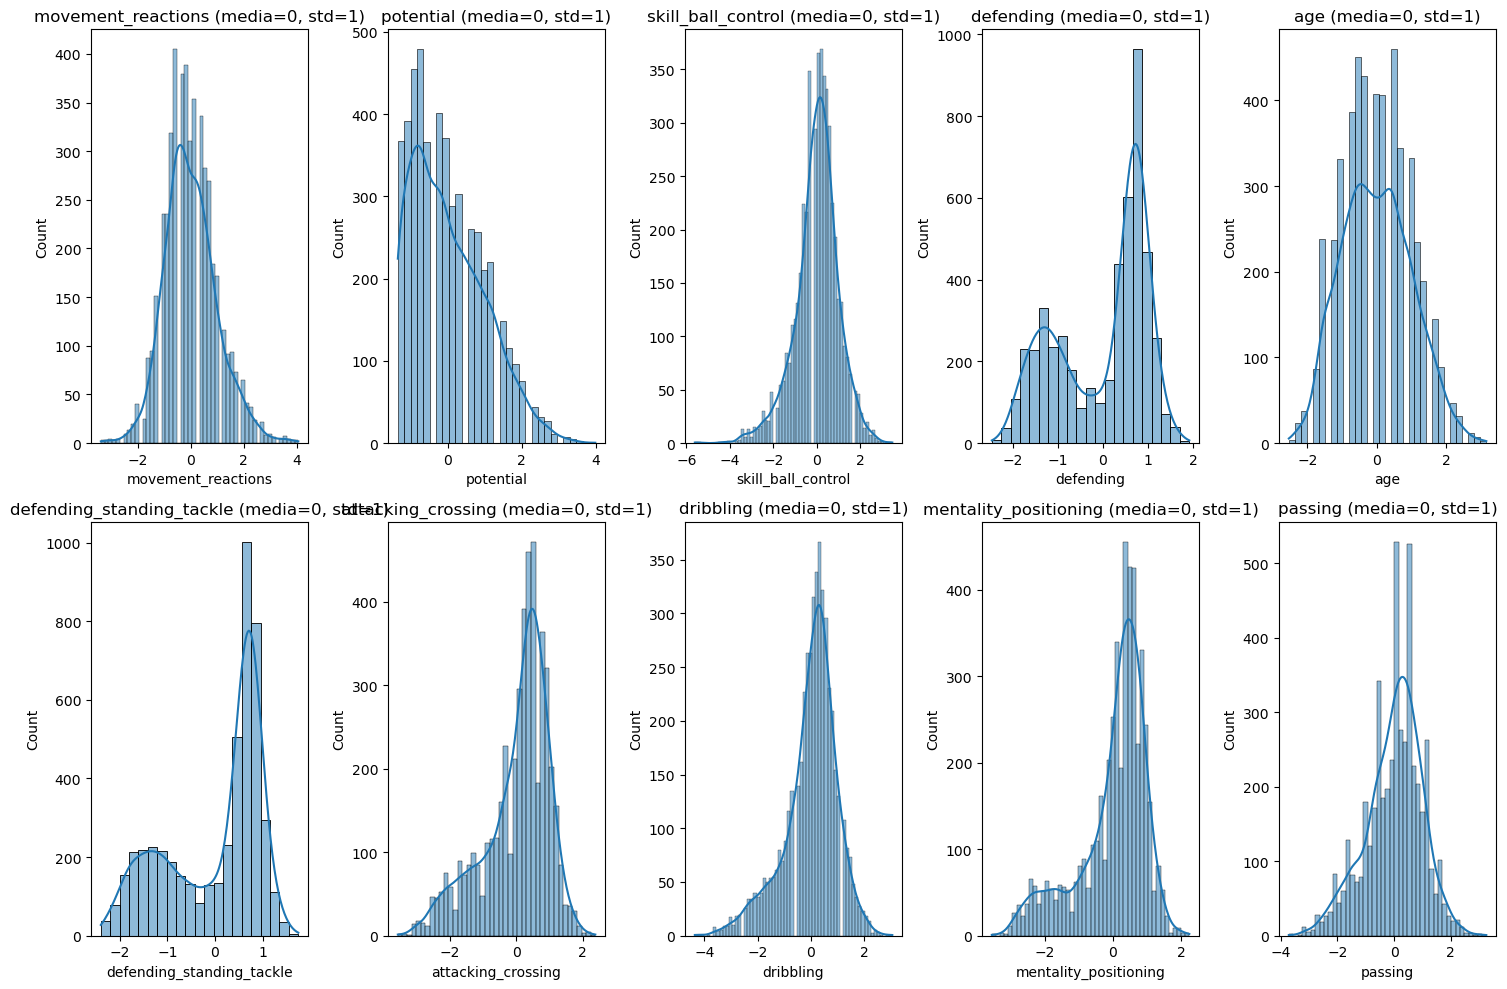

In [623]:
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
top10_importance = importances.head(10)['feature'].tolist()  # Top importance
print("Top 10:", top10_importance)
df_top10 = df_scaled_DataFrame[top10_importance]

plt.figure(figsize=(15, 10))
for i, col in enumerate(top10_importance, 1):
    plt.subplot(2, 5, i)
    sns.histplot(df_top10[col], kde=True)
    plt.title(f'{col} (media=0, std=1)')
plt.tight_layout()
plt.show()

## 4. Reducción de dimensionalidad con PCA 

**Tareas guiadas:**
1. Ajusta **PCA** y representa la **varianza explicada acumulada**.
2. Elige componentes suficientes para ≥ 85–90% de varianza.
3. Visualiza los datos en las **dos primeras componentes**. 
4. Interpreta las **cargas (loadings)** de PCA.


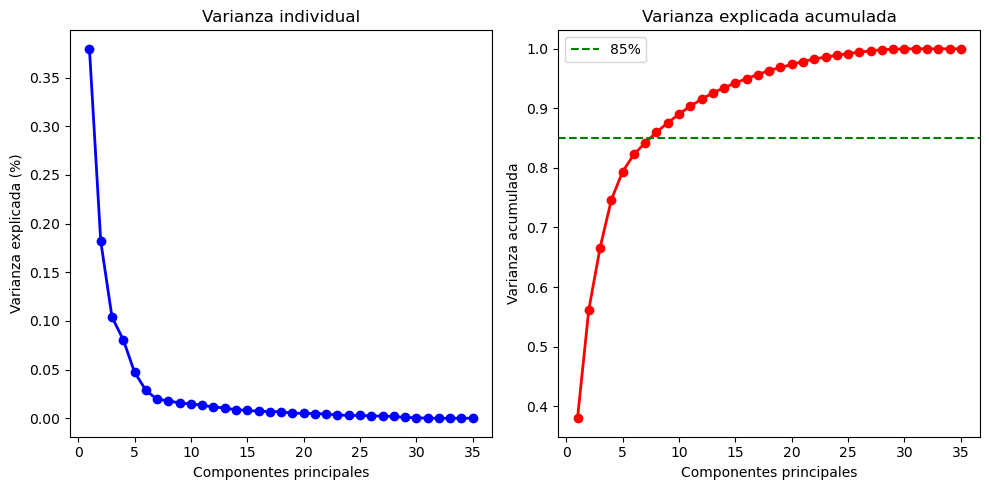

PCs para 85% varianza: 8


In [624]:
# Ahora vamos a aplicar el PCA
# Esto va a ser de gran ayuda para poder visualizar los datos, ya que va a ver que variables están relacionadas entre sí y cuáles no, además de reducir la dimensionalidad del dataset.
# De esta forma agrupa las variables por su similitud y crea unas nuevas que son llamadas componentes principales y que resumen la mayor parte de la información original.
# Luego vamos a ver que tal la varianza explicada, ya que esta dice cuánta información del conjunto de datos conserva cada componente principal. Si la varianza explicada es alta, significa que la componente principal conserva mucha información del conjunto de datos original.
# La acumulada te dice la información retenida al smar componentes. Un ejemplo: si con 10 componentes se llega al 95%, significa que esas 10 nuevas variables conversan el 95% de la estructura de los datos originales
pca_aplicado = PCA()
pca_aplicado.fit(df_scaled_DataFrame)

varianza_explicada_individual = pca_aplicado.explained_variance_ratio_
varianza_explicada_acumulada = np.cumsum(varianza_explicada_individual)

# Gráfico varianza acumulada
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(varianza_explicada_individual)+1), varianza_explicada_individual, 'bo-', linewidth=2)
plt.xlabel('Componentes principales')
plt.ylabel('Varianza explicada (%)')
plt.title('Varianza individual')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(varianza_explicada_acumulada)+1), varianza_explicada_acumulada, 'ro-', linewidth=2)
plt.axhline(y=0.85, color='g', linestyle='--', label='85%')
plt.xlabel('Componentes principales')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada acumulada')
plt.legend()
plt.tight_layout()
plt.show()

print(f"PCs para 85% varianza: {np.argmax(varianza_explicada_acumulada >= 0.85) + 1}")
# En teoría si la curva cumulada sube rápido, es una buena señal --> pocas componentes sirven para resumir bien a los jugadores


In [625]:
# La de la izquierda te dice que la primera componente explica un 38%, la segunda un 188% y así ... concentrando las primeras una gran cantidad de información del dataset.
# Esto significa que varias características del jugador cuentan lo mismo
# La de la derecha te dice que a partir del 15 componente más o menos, la varianza es de un 90%, lo cual significa que puedes pasar de 40 y pico variables a 15 y conservando casi todo el conjunto de datos

In [626]:
# Si yo ahora quiero solo los componentes principales hasta el 85% de la varianza tengo que quedarme con los componentes a la izq de la línea
pca_85 = PCA(n_components=np.argmax(varianza_explicada_acumulada >= 0.85) + 1)
df_pca = pca_85.fit_transform(df_scaled_DataFrame)
print(f"Componentes para 85%: {pca_85.n_components_}")

Componentes para 85%: 8


In [627]:
overall = df['overall'].values 
overall = df.loc[df_scaled_DataFrame.index, 'overall'].values

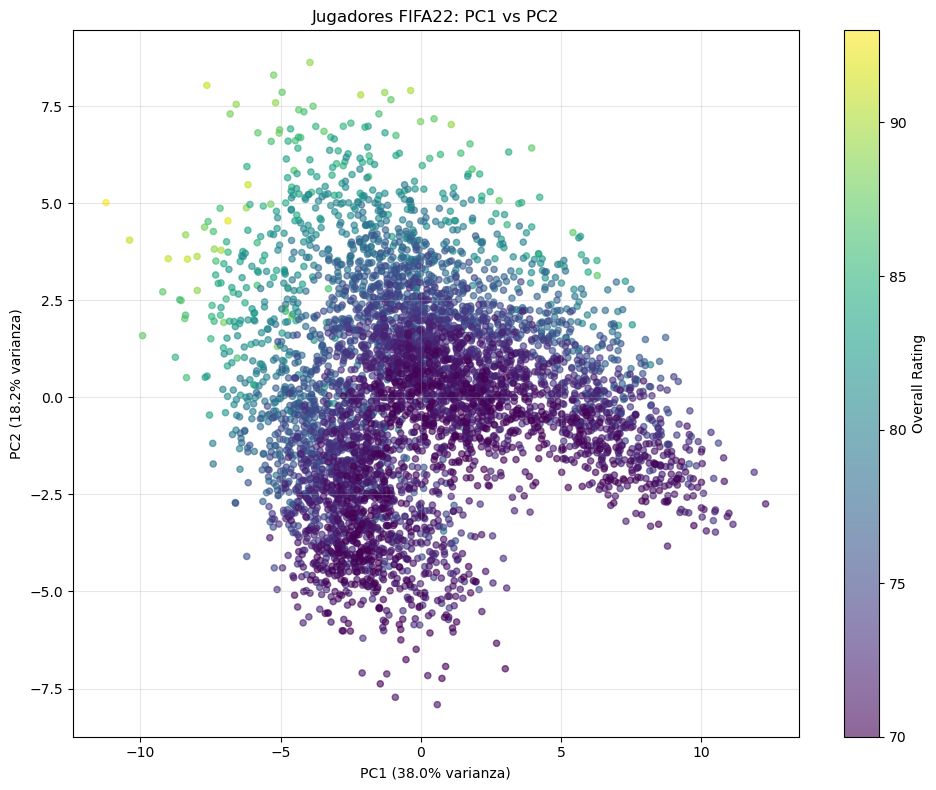

In [628]:
pca = PCA(n_components=8)
df_pca = pca.fit_transform(df_scaled_DataFrame)

# Solo PC1 vs PC2
plt.figure(figsize=(10,8))
scatter = plt.scatter(df_pca[:,0], df_pca[:,1], 
                     c=overall, cmap='viridis', alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.title('Jugadores FIFA22: PC1 vs PC2')
plt.colorbar(scatter, label='Overall Rating')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [629]:
# Cómo interpretar los loadings, que te dicen qué variables originales y cuánto pesan en cada componente
# Regla: loading mayor que 0.3 --> importante
# El loading representa el peso/importancia de cada variable original en esa componente principal
# En este caso vamos a representar los loadings del PC1 y del PC2, que son los que más varianza explican.
# Si el loading es superior a 0.3 quiere decir que este domina ese PC
pca = PCA(n_components=8)
pca.fit(df_scaled_DataFrame)

# DataFrame loadings
loadings_df = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    columns=[f'PC{i+1}' for i in range(8)],
    index=df_scaled_DataFrame.columns
)

# top 5 por PC1 y PC2
print("PC1 top (38% varianza):")
print(loadings_df['PC1'].abs().sort_values(ascending=False).head(10))
print("\nPC2 top (14% varianza):")
print(loadings_df['PC2'].abs().sort_values(ascending=False).head(10))

PC1 top (38% varianza):
dribbling                0.930987
skill_dribbling          0.901243
mentality_positioning    0.853046
shooting                 0.846452
attacking_finishing      0.827218
skill_ball_control       0.823950
mentality_vision         0.801392
skill_curve              0.791859
movement_agility         0.772622
passing                  0.764652
Name: PC1, dtype: float64

PC2 top (14% varianza):
skill_long_passing             0.740054
mentality_interceptions        0.722906
defending                      0.719810
defending_standing_tackle      0.706864
attacking_short_passing        0.697059
defending_marking_awareness    0.693388
defending_sliding_tackle       0.673916
overall                        0.643922
movement_reactions             0.573937
passing                        0.551406
Name: PC2, dtype: float64


## 5. K-Means

**Tareas guiadas:**
1. Aplica **K-Means** sobre `X_pca` con `k ∈ {3,4,8,14}`.
2. Calcula **Inercia (SSE)** y **Silhouette** para cada k.
3. Dibuja **curva del codo** y **silhouette vs k**.
4. Visualiza los clusters en PC1–PC2 y **comenta** si son interpretables.


k=3: silhouette=0.2415, inercia=84096
k=4: silhouette=0.2255, inercia=73544
k=8: silhouette=0.1883, inercia=53924
k=14: silhouette=0.1496, inercia=44156


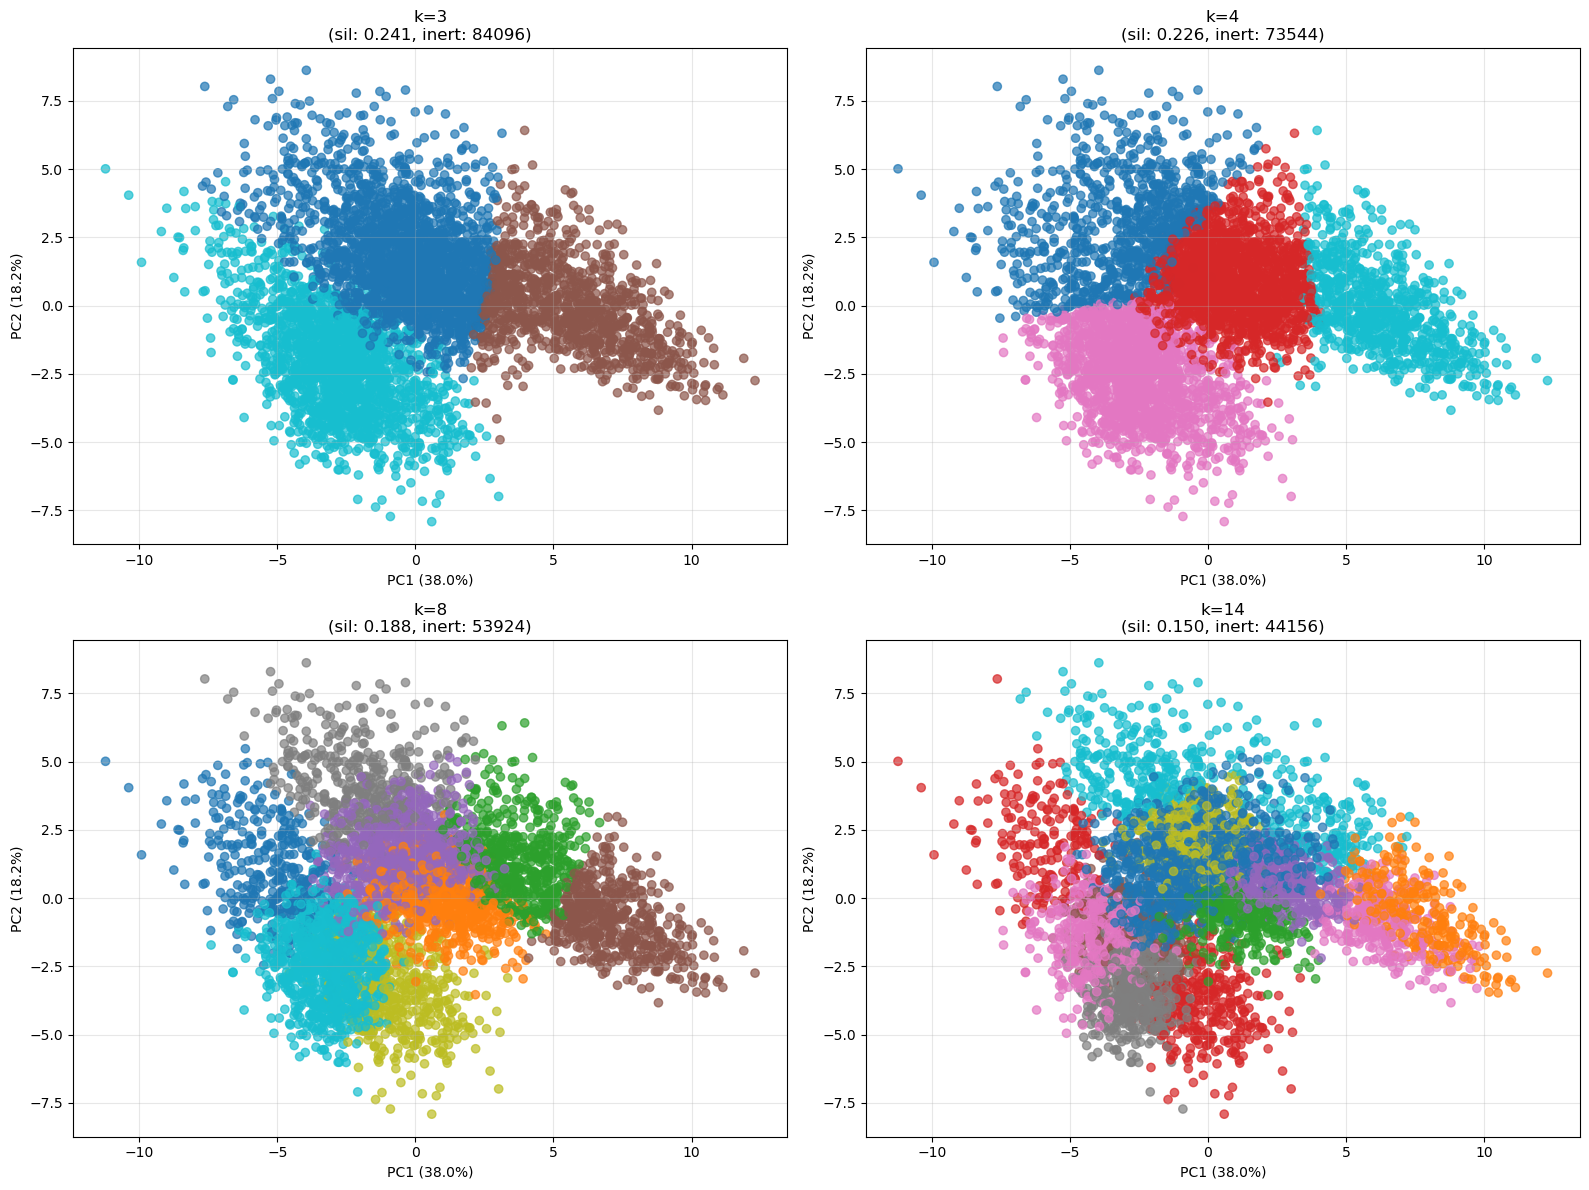

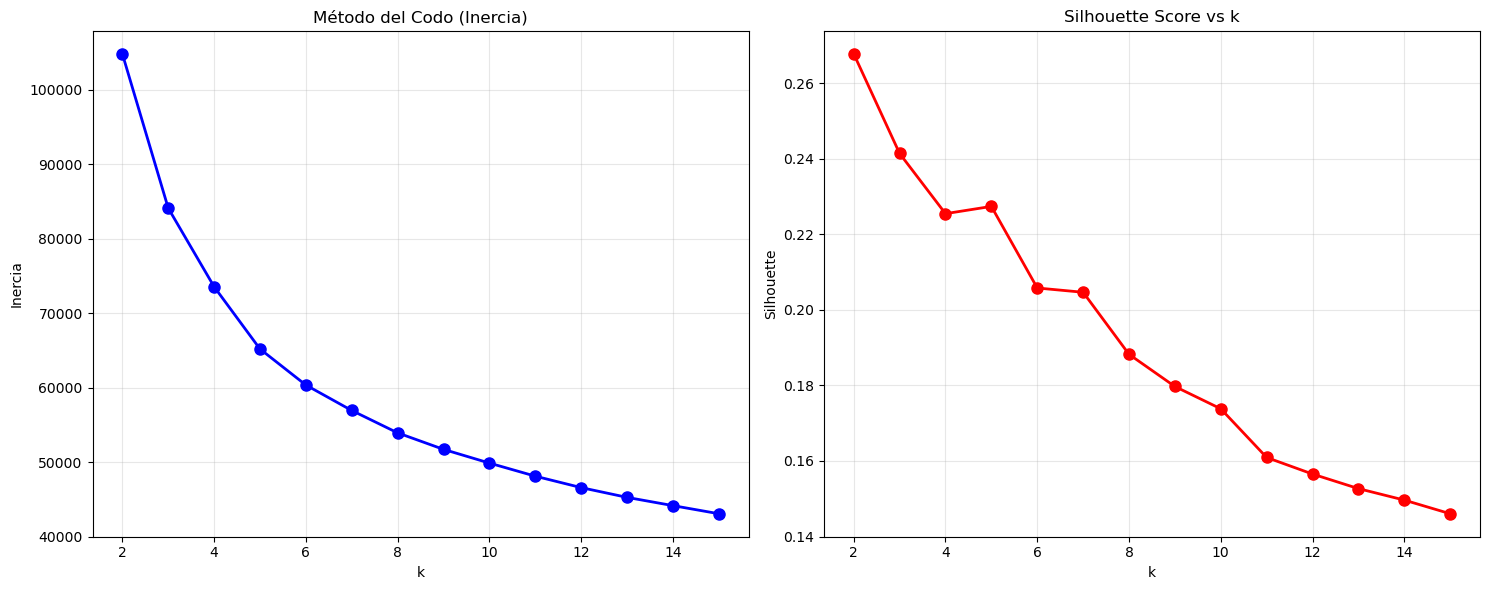

KS ESPECÍFICOS:
    k  silhouette_score     inertia
0   3            0.2415  84095.8337
1   4            0.2255  73544.3563
2   8            0.1883  53924.0012
3  14            0.1496  44155.9556

Mejor k total (silhouette): 2 (score: 0.268)


In [630]:
ks = [3, 4, 8, 14]
silhouette_scores = []
inertia_scores = []

# Gráficos específicos ks + Elbow/Silhouette general
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, k in enumerate(ks):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_pca)
    
    sil_score = silhouette_score(df_pca, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia_scores.append(kmeans.inertia_)
    
    print(f'k={k}: silhouette={sil_score:.4f}, inercia={kmeans.inertia_:.0f}')
    
    # Visualización PC1-PC2
    ax = axes[i//2, i%2]
    scatter = ax.scatter(df_pca[:,0], df_pca[:,1], c=cluster_labels, 
                        cmap='tab10', alpha=0.7)
    ax.set_title(f'k={k}\n(sil: {sil_score:.3f}, inert: {kmeans.inertia_:.0f})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Elbow + Silhouette (rango completo)
K_range = range(2, 16)
inertia_full = []; silhouette_full = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca)
    inertia_full.append(km.inertia_)
    silhouette_full.append(silhouette_score(df_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(K_range, inertia_full, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('k'); ax1.set_ylabel('Inercia'); ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_full, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score vs k')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
results = pd.DataFrame({
    'k': ks, 
    'silhouette_score': silhouette_scores,
    'inertia': inertia_scores
})
print("KS ESPECÍFICOS:")
print(results.sort_values('silhouette_score', ascending=False).round(4))

print(f"\nMejor k total (silhouette): {np.argmax(silhouette_full)+2} (score: {max(silhouette_full):.3f})")

# Cuando la inercia es más baja, mejor es la k y cuando la silhouette es más alta, mejor es la k.
# La inercia indica que tan cerca están los puntos de cada cluster, aunque a una k más alta más riesgo de segmentación
# La silhouette indica que tan separados están los clusters, pero el problema es que aquí se pueden separar demasiado los clusteres.

In [631]:
# Se concluye que el mejor es el k=3, clusters moderamente separados
# Además, en la gráfica del codo se puede observar como con k=3 se produce una caída muy agravada y luego las caídas son más suaves, lo cual es una señal de que k=3 es un buen número de clusters.
# En cuánto al silhouette, lo que se busca es el valor más alto posible, entonces con k=3 sigue siendo un buen valor, aunque no sea el máximo.

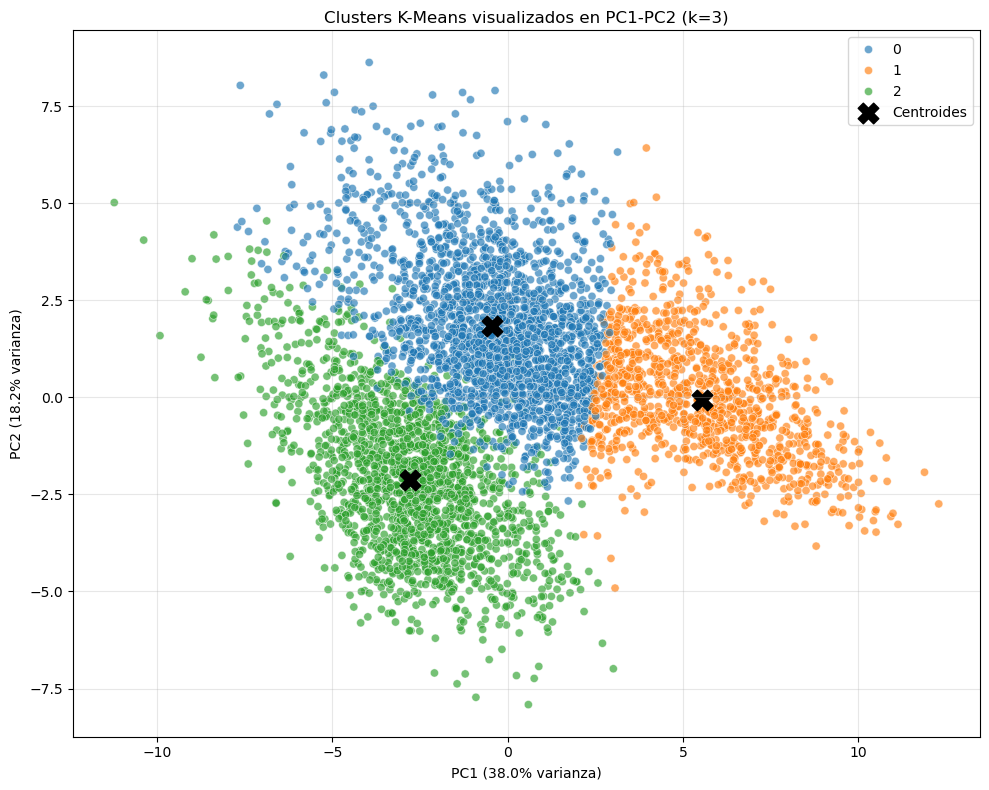

In [632]:
# K elegido es igual a 3
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_pca)

# DataFrame para graficar
df_plot = pd.DataFrame({
    'PC1': df_pca[:, 0],
    'PC2': df_pca[:, 1],
    'cluster': cluster_labels
})

# Centroides en espacio PCA
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_plot,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.65,
    s=35
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    s=220,
    marker='X',
    label='Centroides'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.title(f'Clusters K-Means visualizados en PC1-PC2 (k={k})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Al estar los tres claramente diferenciados se puede afirmar que sí, que son razonablemente interpreables en las dos primeras componentes principales

## 6. Clustering Jerárquico (HC)

**Tareas guiadas:**
1. Usa **AgglomerativeClustering** con `linkage`: `ward`, `complete`, `average`, `single`.
2. Métrica: Euclídea (Manhattan cuando sea compatible).
3. Representa **dendrograma** (con `scipy` + `linkage`).
4. Calcula **Silhouette** y compara con K-Means.


##  7. DBSCAN

**Tareas guiadas:**
1. Estima `eps` con el **k-distance plot** (`NearestNeighbors`).
2. Prueba varios `eps` y `min_samples`.
3. Cuenta nº de clústeres y **ruido**.
4. Calcula **Silhouette** (excluyendo ruido) y compara.


## 8. Comparativa de modelos

Completa y amplia con los resultados de tus experimentos:

| Modelo       | Configuración             | Nº clusters | Silhouette | Observaciones |
|:-------------|:--------------------------|------------:|-----------:|:--------------|
| K-Means      | PCA + k=3                 |             |            |               |
| Hierarchical | Ward                      |             |            |               |
| DBSCAN       | eps=?, min_samples=?      |             |            |               |

**Reflexiona:**
- ¿Qué modelo ofrece agrupamientos más interpretables?
- ¿Influye PCA en la calidad del clustering?
- ¿Qué atributos parecen definir mejor los roles?


## 9. Conclusiones

**Preguntas guía:**
- ¿Qué algoritmo separa mejor los grupos?
- ¿Cómo ayuda PCA a visualizar e interpretar?
- ¿Qué mejoras propondrías? (p. ej., usar otras métricas como **Davies–Bouldin**, o sub-clustering por rol).


## Referencias
- *Clustering in Game Analysis on FIFA22 Official Players Data*, IEEE AiDAS (2022).
- Scikit-learn: https://scikit-learn.org/stable/modules/clustering.html
- Kaggle: *FIFA Player Stats Database* (players_22.csv)
